# Loan Approval Prediction

## Problem Definition
Predicting whether a loan application will be approved or rejected based on the applicant's personal, financial, and credit-related information.

- Learning type: Supervised Learning
- Problem type: Binary Classification
- Algorithm: Decision Tree
- Target: Loan_Status (Y = Approved, N = Rejected)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RANDOM_STATE = 42

In [2]:
import kagglehub

dataset_path = Path(kagglehub.dataset_download("saunakrath/dataset"))

print("Dataset path:", dataset_path)
print("\nFiles in dataset:")
for file in dataset_path.iterdir():
    print(file.name)

Dataset path: C:\Users\Abdel\.cache\kagglehub\datasets\saunakrath\dataset\versions\1

Files in dataset:
dataset.csv
test.csv
train.csv


In [3]:
import shutil

project_root = Path.cwd().parent
raw_dir = project_root / "data" / "raw"
raw_dir.mkdir(parents=True, exist_ok=True)

raw_path = raw_dir / "loan_approval.csv"
shutil.copy2(dataset_path / "train.csv", raw_path)

print("Saved to:", raw_path)

Saved to: c:\PROJECT\ML_PROJECT\Loan-approval-project\data\raw\loan_approval.csv


In [4]:
df = pd.read_csv(raw_path)

print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
for name in ["dataset.csv", "test.csv"]:
    tmp = pd.read_csv(dataset_path / name)
    print(name, "| shape:", tmp.shape, "| has Loan_Status:", "Loan_Status" in tmp.columns)

dataset.csv | shape: (614, 13) | has Loan_Status: False
test.csv | shape: (367, 12) | has Loan_Status: False


In [6]:
print("Shape:", df.shape)
print()
df.info()

Shape: (614, 13)

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [7]:
missing = df.isna().sum()
print("Missing values per column:")
print(missing[missing > 0].to_string())
print()
print("Total missing cells:", missing.sum())
print("Duplicated rows:", df.duplicated().sum())
print("Duplicated Loan_ID:", df["Loan_ID"].duplicated().sum())

Missing values per column:
Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50

Total missing cells: 149
Duplicated rows: 0
Duplicated Loan_ID: 0


In [8]:
print(df["Loan_Status"].value_counts())
print()
print(df["Loan_Status"].value_counts(normalize=True).round(4))

Loan_Status
Y    422
N    192
Name: count, dtype: int64

Loan_Status
Y    0.6873
N    0.3127
Name: proportion, dtype: float64


In [9]:
cat_cols = df.select_dtypes(exclude="number").columns.drop("Loan_ID")

for col in cat_cols:
    print(f"{col}: {df[col].value_counts(dropna=False).to_dict()}")

print()
print("Credit_History:", df["Credit_History"].value_counts(dropna=False).to_dict())

Gender: {'Male': 489, 'Female': 112, nan: 13}
Married: {'Yes': 398, 'No': 213, nan: 3}
Dependents: {'0': 345, '1': 102, '2': 101, '3+': 51, nan: 15}
Education: {'Graduate': 480, 'Not Graduate': 134}
Self_Employed: {'No': 500, 'Yes': 82, nan: 32}
Property_Area: {'Semiurban': 233, 'Urban': 202, 'Rural': 179}
Loan_Status: {'Y': 422, 'N': 192}

Credit_History: {1.0: 475, 0.0: 89, nan: 50}


In [10]:
df[["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]].describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0


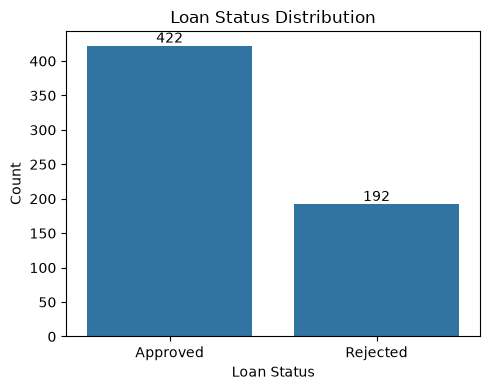

In [11]:
status_labels = {"Y": "Approved", "N": "Rejected"}

plt.figure(figsize=(5, 4))
ax = sns.countplot(x=df["Loan_Status"].map(status_labels), order=["Approved", "Rejected"])
for container in ax.containers:
    ax.bar_label(container)
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Skewness:
ApplicantIncome      6.5395
CoapplicantIncome    7.4915
LoanAmount           2.6776
Loan_Amount_Term    -2.3624


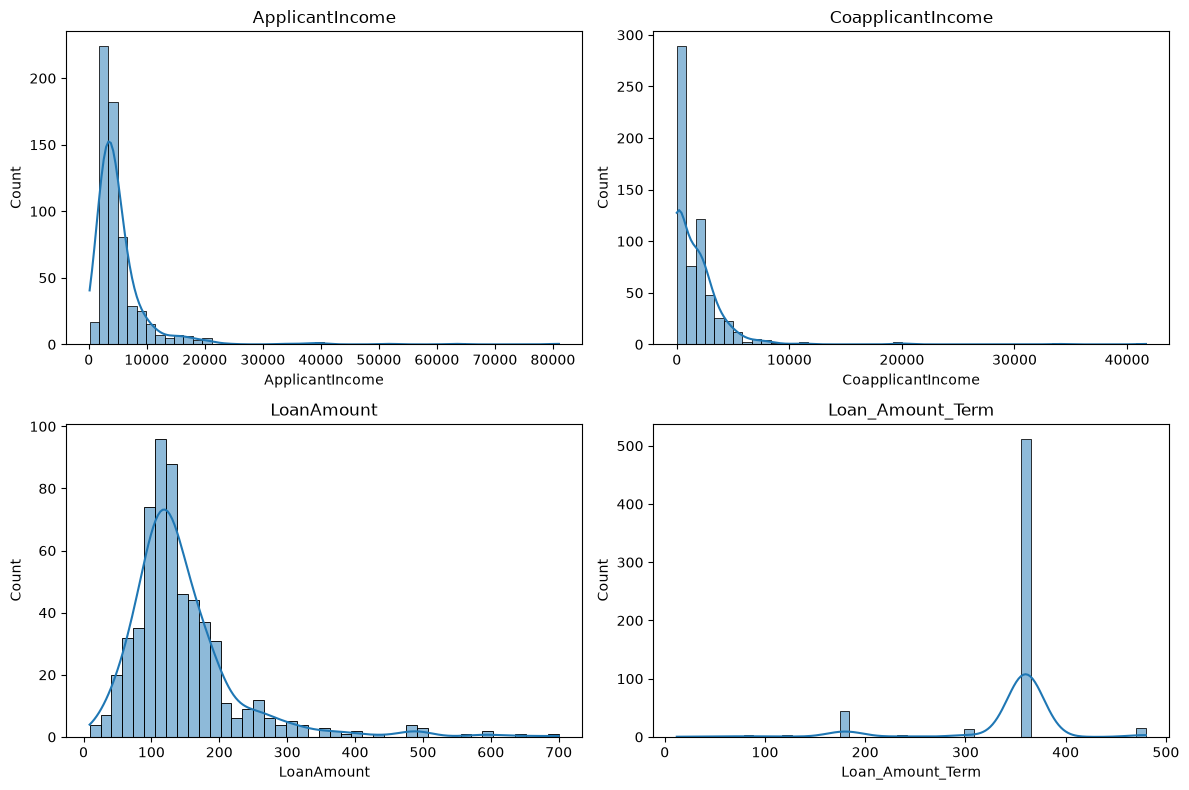

In [12]:
num_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]

print("Skewness:")
print(df[num_cols].skew().round(4).to_string())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Loan_Status             N       Y
ApplicantIncome    3833.5  3812.5
CoapplicantIncome   268.0  1239.5
LoanAmount          129.0   126.0
Loan_Amount_Term    360.0   360.0


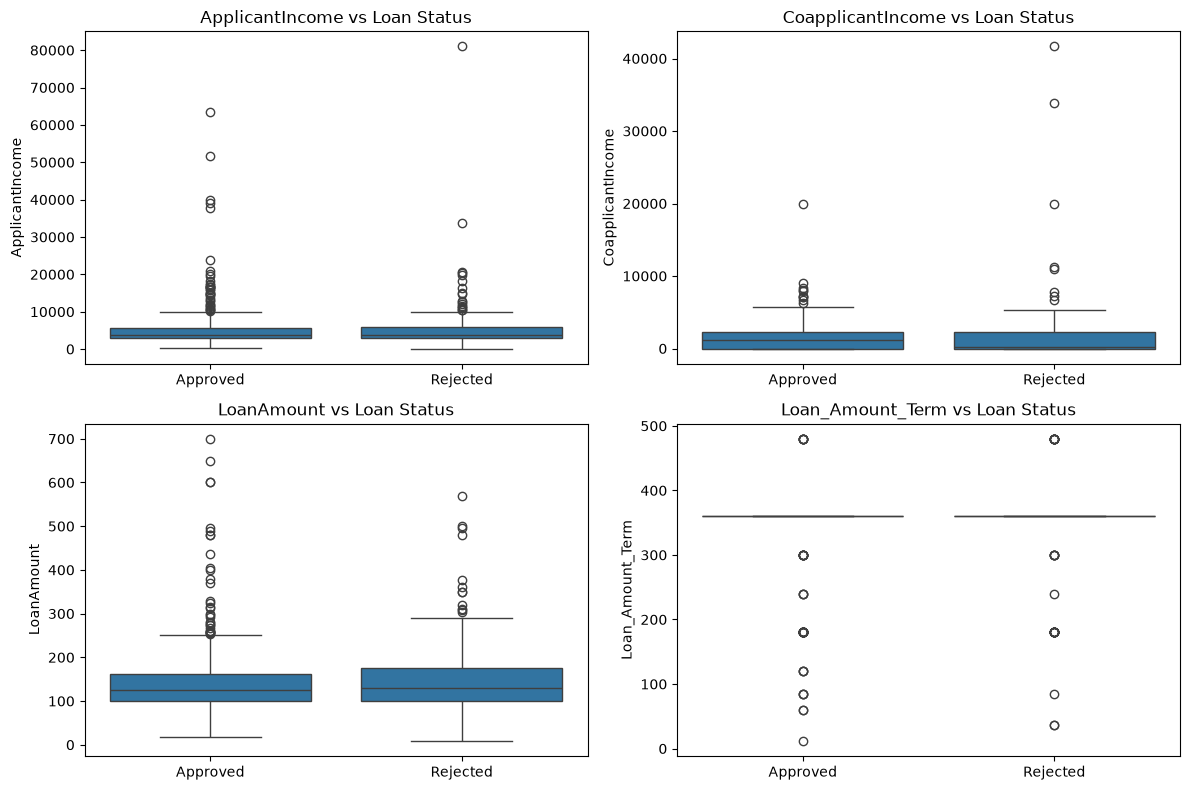

In [13]:
print(df.groupby("Loan_Status")[num_cols].median().round(2).T.to_string())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(x=df["Loan_Status"].map(status_labels), y=df[col],
                order=["Approved", "Rejected"], ax=ax)
    ax.set_title(f"{col} vs Loan Status")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [14]:
cat_features = ["Gender", "Married", "Dependents", "Education",
                "Self_Employed", "Property_Area", "Credit_History"]

for col in cat_features:
    grouped = (
        df.groupby(df[col].astype("object").fillna("Missing"))["Loan_Status"]
        .agg(count="size", approved_pct=lambda s: round((s == "Y").mean() * 100, 2))
    )
    print(f"\n{col}")
    print(grouped.to_string())


Gender
         count  approved_pct
Gender                      
Female     112         66.96
Male       489         69.33
Missing     13         61.54

Married
         count  approved_pct
Married                     
Missing      3        100.00
No         213         62.91
Yes        398         71.61

Dependents
            count  approved_pct
Dependents                     
0             345         68.99
1             102         64.71
2             101         75.25
3+             51         64.71
Missing        15         60.00

Education
              count  approved_pct
Education                        
Graduate        480         70.83
Not Graduate    134         61.19

Self_Employed
               count  approved_pct
Self_Employed                     
Missing           32         71.88
No               500         68.60
Yes               82         68.29

Property_Area
               count  approved_pct
Property_Area                     
Rural            179         61.45


In [15]:
for col in ["Education", "Self_Employed", "Property_Area"]:
    grouped = (
        df.groupby(df[col].astype("object").fillna("Missing"))["Loan_Status"]
        .agg(count="size", approved_pct=lambda s: round((s == "Y").mean() * 100, 2))
    )
    print(f"\n{col}")
    print(grouped.to_string())


Education
              count  approved_pct
Education                        
Graduate        480         70.83
Not Graduate    134         61.19

Self_Employed
               count  approved_pct
Self_Employed                     
Missing           32         71.88
No               500         68.60
Yes               82         68.29

Property_Area
               count  approved_pct
Property_Area                     
Rural            179         61.45
Semiurban        233         76.82
Urban            202         65.84


In [16]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Loan_ID", "Loan_Status"])
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print()
print("Train target distribution:")
print(y_train.value_counts())
print()
print("Test target distribution:")
print(y_test.value_counts())

X_train: (491, 11)
X_test: (123, 11)

Train target distribution:
Loan_Status
Y    337
N    154
Name: count, dtype: int64

Test target distribution:
Loan_Status
Y    85
N    38
Name: count, dtype: int64


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

num_features = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]
cat_features = ["Gender", "Married", "Dependents", "Education",
                "Self_Employed", "Credit_History", "Property_Area"]


def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), num_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]), cat_features),
        ]
    )


print("Numerical:", num_features)
print("Categorical:", cat_features)

Numerical: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
Categorical: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area']


In [18]:
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, recall_score, precision_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "recall_macro": "recall_macro",
    "recall_N": make_scorer(recall_score, pos_label="N"),
    "precision_N": make_scorer(precision_score, pos_label="N", zero_division=0),
    "roc_auc": "roc_auc",
}

baselines = {
    "Dummy (always Approved)": DummyClassifier(strategy="most_frequent"),
    "Tree depth 1 (stump)": DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
    "Tree fully grown": DecisionTreeClassifier(random_state=RANDOM_STATE),
}

rows = []
for name, clf in baselines.items():
    pipe = Pipeline([("preprocessor", make_preprocessor()), ("model", clf)])
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    row = {"Model": name}
    for metric in scoring:
        scores = res[f"test_{metric}"]
        row[metric] = f"{scores.mean():.4f} ± {scores.std():.4f}"
    rows.append(row)

baseline_df = pd.DataFrame(rows).set_index("Model")
baseline_df

,accuracy,recall_macro,recall_N,precision_N,roc_auc
Model,,,,,
Dummy (always Approved),0.6864 ± 0.0040,0.5000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.5000 ± 0.0000
Tree depth 1 (stump),0.7983 ± 0.0457,0.6892 ± 0.0633,0.3961 ± 0.1125,0.8923 ± 0.1244,0.6892 ± 0.0633
Tree fully grown,0.6965 ± 0.0252,0.6415 ± 0.0316,0.4935 ± 0.0747,0.5191 ± 0.0425,0.6415 ± 0.0316


In [19]:
from sklearn.tree import export_text

stump = Pipeline([
    ("preprocessor", make_preprocessor()),
    ("model", DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)),
])
stump.fit(X_train, y_train)

feature_names = list(stump.named_steps["preprocessor"].get_feature_names_out())
print(export_text(stump.named_steps["model"], feature_names=feature_names))

|--- cat__Credit_History_1.0 <= 0.50
|   |--- class: N
|--- cat__Credit_History_1.0 >  0.50
|   |--- class: Y



max_depth  train_recall_macro  cv_recall_macro  cv_std
        1              0.6892           0.6892  0.0633
        2              0.6990           0.6832  0.0596
        3              0.7112           0.6735  0.0530
        4              0.7306           0.6676  0.0560
        5              0.7488           0.6587  0.0371
        6              0.7908           0.6323  0.0345
        8              0.8578           0.6537  0.0319
       10              0.9273           0.6564  0.0307
       12              0.9637           0.6452  0.0338
       15              0.9883           0.6504  0.0340
     None              1.0000           0.6415  0.0316


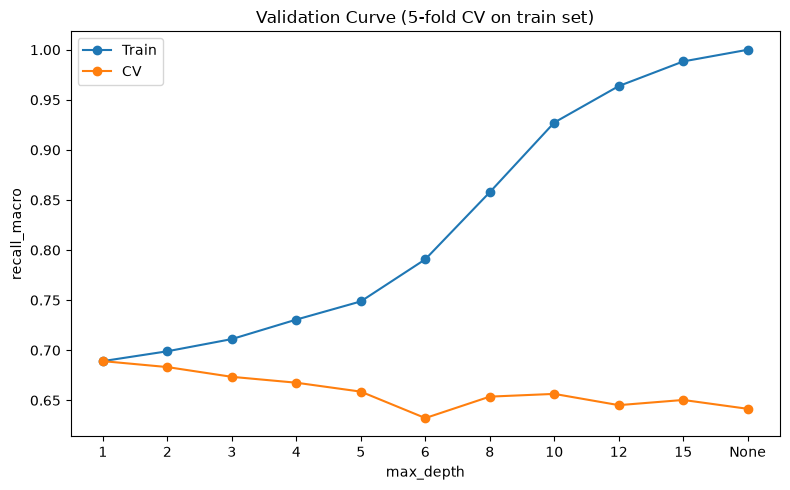

In [20]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, None]

rows = []
for d in depths:
    pipe = Pipeline([
        ("preprocessor", make_preprocessor()),
        ("model", DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)),
    ])
    res = cross_validate(pipe, X_train, y_train, cv=cv,
                         scoring="recall_macro", return_train_score=True)
    rows.append({
        "max_depth": "None" if d is None else d,
        "train_recall_macro": res["train_score"].mean(),
        "cv_recall_macro": res["test_score"].mean(),
        "cv_std": res["test_score"].std(),
    })

depth_df = pd.DataFrame(rows)
print(depth_df.round(4).to_string(index=False))

plt.figure(figsize=(8, 5))
x = range(len(depth_df))
plt.plot(x, depth_df["train_recall_macro"], marker="o", label="Train")
plt.plot(x, depth_df["cv_recall_macro"], marker="o", label="CV")
plt.xticks(x, depth_df["max_depth"].astype(str))
plt.xlabel("max_depth")
plt.ylabel("recall_macro")
plt.title("Validation Curve (5-fold CV on train set)")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ("preprocessor", make_preprocessor()),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [1, 2, 3, 4, 5, None],
    "model__min_samples_leaf": [1, 5, 10, 20],
    "model__ccp_alpha": [0.0, 0.002, 0.005, 0.01, 0.02],
    "model__class_weight": [None, "balanced"],
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="recall_macro",
    n_jobs=-1,
    refit=True,
)
grid.fit(X_train, y_train)

print("Combinations tried:", len(grid.cv_results_["params"]))
print("Best params:", grid.best_params_)
print("Best CV recall_macro:", round(grid.best_score_, 4))

Combinations tried: 480
Best params: {'model__ccp_alpha': 0.005, 'model__class_weight': None, 'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_leaf': 1}
Best CV recall_macro: 0.6926


In [22]:
results = pd.DataFrame(grid.cv_results_)
top = (
    results[["params", "mean_test_score", "std_test_score", "rank_test_score"]]
    .sort_values("rank_test_score")
    .head(10)
    .copy()
)
top["params"] = top["params"].astype(str)
pd.set_option("display.max_colwidth", None)
print(top.round(4).to_string(index=False))

                                                                                                                                         params  mean_test_score  std_test_score  rank_test_score
   {'model__ccp_alpha': 0.005, 'model__class_weight': None, 'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_leaf': 1}           0.6926          0.0458                1
      {'model__ccp_alpha': 0.005, 'model__class_weight': None, 'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_leaf': 1}           0.6896          0.0443                2
  {'model__ccp_alpha': 0.005, 'model__class_weight': None, 'model__criterion': 'entropy', 'model__max_depth': 3, 'model__min_samples_leaf': 10}           0.6894          0.0634                3
    {'model__ccp_alpha': 0.0, 'model__class_weight': None, 'model__criterion': 'entropy', 'model__max_depth': 3, 'model__min_samples_leaf': 10}           0.6894          0.0634                3
  {'model__ccp_alpha': 0.002, 

In [23]:
stumps = results[results["param_model__max_depth"] == 1].sort_values("rank_test_score")
best_stump = stumps.iloc[0]

print("Best stump in grid:")
print("  params:", best_stump["params"])
print(f"  recall_macro: {best_stump['mean_test_score']:.4f} ± {best_stump['std_test_score']:.4f}")
print("  rank:", int(best_stump["rank_test_score"]))

best_tree = grid.best_estimator_.named_steps["model"]
print()
print("Best model depth:", best_tree.get_depth())
print("Best model leaves:", best_tree.get_n_leaves())

Best stump in grid:
  params: {'model__ccp_alpha': 0.0, 'model__class_weight': None, 'model__criterion': 'gini', 'model__max_depth': 1, 'model__min_samples_leaf': 1}
  recall_macro: 0.6892 ± 0.0633
  rank: 8

Best model depth: 6
Best model leaves: 9


In [24]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

final_model = grid.best_estimator_

dummy = Pipeline([("preprocessor", make_preprocessor()),
                  ("model", DummyClassifier(strategy="most_frequent"))]).fit(X_train, y_train)
stump = Pipeline([("preprocessor", make_preprocessor()),
                  ("model", DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE))]).fit(X_train, y_train)


def compute_metrics(y_true, y_pred, scores):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Rejected precision": precision_score(y_true, y_pred, pos_label="N", zero_division=0),
        "Rejected recall": recall_score(y_true, y_pred, pos_label="N"),
        "Rejected F1": f1_score(y_true, y_pred, pos_label="N", zero_division=0),
        "Recall (macro)": recall_score(y_true, y_pred, average="macro"),
        "ROC-AUC": roc_auc_score((np.asarray(y_true) == "Y").astype(int), scores),
    }


def get_predictions(model):
    pred = model.predict(X_test)
    score = model.predict_proba(X_test)[:, list(model.classes_).index("Y")]
    return pred, score


y_pred, scores = get_predictions(final_model)
test_metrics = compute_metrics(y_test, y_pred, scores)

table = {"Final tree": test_metrics}
for name, m in [("Dummy", dummy), ("Stump", stump)]:
    p, s = get_predictions(m)
    table[name] = compute_metrics(y_test, p, s)

print(pd.DataFrame(table).round(4).to_string())

print()
cm = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=["N", "Y"]),
    index=["True Rejected", "True Approved"],
    columns=["Pred Rejected", "Pred Approved"],
)
print("Final tree confusion matrix:")
print(cm)

print()
print(classification_report(y_test, y_pred, labels=["N", "Y"],
                            target_names=["Rejected", "Approved"], digits=4))

                    Final tree   Dummy   Stump
Accuracy                0.8537  0.6911  0.8537
Rejected precision      0.8571  0.0000  0.9545
Rejected recall         0.6316  0.0000  0.5526
Rejected F1             0.7273  0.0000  0.7000
Recall (macro)          0.7923  0.5000  0.7704
ROC-AUC                 0.7621  0.5000  0.7704

Final tree confusion matrix:
               Pred Rejected  Pred Approved
True Rejected             24             14
True Approved              4             81

              precision    recall  f1-score   support

    Rejected     0.8571    0.6316    0.7273        38
    Approved     0.8526    0.9529    0.9000        85

    accuracy                         0.8537       123
   macro avg     0.8549    0.7923    0.8136       123
weighted avg     0.8540    0.8537    0.8466       123



In [25]:
rng = np.random.RandomState(RANDOM_STATE)

y_true_arr = y_test.to_numpy()
y_pred_arr = np.asarray(y_pred)
scores_arr = np.asarray(scores)
n = len(y_true_arr)

boot = {name: [] for name in test_metrics}
for _ in range(1000):
    idx = rng.randint(0, n, n)
    if len(np.unique(y_true_arr[idx])) < 2:
        continue
    m = compute_metrics(y_true_arr[idx], y_pred_arr[idx], scores_arr[idx])
    for name, value in m.items():
        boot[name].append(value)

ci_rows = []
for name, values in boot.items():
    low, high = np.percentile(values, [2.5, 97.5])
    ci_rows.append({
        "Metric": name,
        "Test score": round(test_metrics[name], 4),
        "95% CI": f"[{low:.4f}, {high:.4f}]",
    })

print("Valid resamples:", len(boot["Accuracy"]))
print(pd.DataFrame(ci_rows).to_string(index=False))

Valid resamples: 1000
            Metric  Test score           95% CI
          Accuracy      0.8537 [0.7886, 0.9108]
Rejected precision      0.8571 [0.7241, 0.9667]
   Rejected recall      0.6316 [0.4827, 0.7941]
       Rejected F1      0.7273 [0.5937, 0.8379]
    Recall (macro)      0.7923 [0.7121, 0.8743]
           ROC-AUC      0.7621 [0.6608, 0.8597]


In [26]:
errors = X_test.copy()
errors["true"] = y_test
errors["pred"] = y_pred
errors["p_approved"] = scores
errors["error_type"] = np.where(
    (errors["true"] == "N") & (errors["pred"] == "Y"), "Missed rejection (N predicted Y)",
    np.where((errors["true"] == "Y") & (errors["pred"] == "N"),
             "Wrongly rejected (Y predicted N)", "Correct"),
)

print(errors["error_type"].value_counts().to_string())
print()
print("Predicted approval probability by error type:")
print(errors.groupby("error_type")["p_approved"].agg(["count", "mean", "min", "max"]).round(4).to_string())
print()
print("Credit_History vs (true, predicted) on the test set:")
print(pd.crosstab(errors["Credit_History"].astype("object").fillna("Missing"),
                  [errors["true"], errors["pred"]]).to_string())

error_type
Correct                             105
Missed rejection (N predicted Y)     14
Wrongly rejected (Y predicted N)      4

Predicted approval probability by error type:
                                  count    mean    min     max
error_type                                                    
Correct                             105  0.6481  0.000  1.0000
Missed rejection (N predicted Y)     14  0.8231  0.766  0.9259
Wrongly rejected (Y predicted N)      4  0.0224  0.000  0.0896

Credit_History vs (true, predicted) on the test set:
true             N      Y    
pred             N   Y  N   Y
Credit_History               
0.0             21   0  1   0
1.0              3  14  3  74
Missing          0   0  0   7


In [27]:
missed = errors[errors["error_type"].str.startswith("Missed")]
caught = errors[(errors["true"] == "N") & (errors["pred"] == "N")]
ok_appr = errors[(errors["true"] == "Y") & (errors["pred"] == "Y")]

groups = {"Missed rejection": missed, "Caught rejection": caught, "Correct approval": ok_appr}

print("Group sizes:", {k: len(g) for k, g in groups.items()})
print()
print("Median of numerical features:")
print(pd.DataFrame({k: g[num_features].median() for k, g in groups.items()}).round(2).to_string())
print()
print("Share of each category value (%):")
checks = [("Credit_History", 1.0), ("Married", "Yes"), ("Education", "Graduate"),
          ("Property_Area", "Semiurban"), ("Dependents", "0"),
          ("Self_Employed", "Yes"), ("Gender", "Male")]
share = {f"{c}={v}": {k: round((g[c] == v).mean() * 100, 1) for k, g in groups.items()}
         for c, v in checks}
print(pd.DataFrame(share).T.to_string())

Group sizes: {'Missed rejection': 14, 'Caught rejection': 24, 'Correct approval': 81}

Median of numerical features:
                   Missed rejection  Caught rejection  Correct approval
ApplicantIncome              3508.0            3081.5            3707.0
CoapplicantIncome            1445.0            1365.5            1600.0
LoanAmount                    150.0             121.0             120.0
Loan_Amount_Term              360.0             360.0             360.0

Share of each category value (%):
                         Missed rejection  Caught rejection  Correct approval
Credit_History=1.0                  100.0              12.5              91.4
Married=Yes                          57.1              45.8              74.1
Education=Graduate                   85.7              70.8              86.4
Property_Area=Semiurban              14.3              45.8              43.2
Dependents=0                         57.1              41.7              58.0
Self_Employed=Yes   

In [28]:
final_tree = final_model.named_steps["model"]
names = list(final_model.named_steps["preprocessor"].get_feature_names_out())
print(export_text(final_tree, feature_names=names, show_weights=True))

|--- cat__Credit_History_1.0 <= 0.50
|   |--- weights: [61.00, 6.00] class: N
|--- cat__Credit_History_1.0 >  0.50
|   |--- num__CoapplicantIncome <= 9537.00
|   |   |--- num__ApplicantIncome <= 3357.50
|   |   |   |--- num__LoanAmount <= 76.50
|   |   |   |   |--- weights: [11.00, 24.00] class: Y
|   |   |   |--- num__LoanAmount >  76.50
|   |   |   |   |--- num__LoanAmount <= 164.00
|   |   |   |   |   |--- weights: [8.00, 100.00] class: Y
|   |   |   |   |--- num__LoanAmount >  164.00
|   |   |   |   |   |--- num__CoapplicantIncome <= 2824.50
|   |   |   |   |   |   |--- weights: [4.00, 1.00] class: N
|   |   |   |   |   |--- num__CoapplicantIncome >  2824.50
|   |   |   |   |   |   |--- weights: [0.00, 7.00] class: Y
|   |   |--- num__ApplicantIncome >  3357.50
|   |   |   |--- num__LoanAmount <= 95.50
|   |   |   |   |--- cat__Education_Not Graduate <= 0.50
|   |   |   |   |   |--- weights: [7.00, 18.00] class: Y
|   |   |   |   |--- cat__Education_Not Graduate >  0.50
|   |   |  

In [29]:
pre = final_model.named_steps["preprocessor"]
train_leaf = final_tree.apply(pre.transform(X_train))
test_leaf = final_tree.apply(pre.transform(X_test))

train_ct = pd.crosstab(train_leaf, y_train.to_numpy()).rename(columns={"N": "train_N", "Y": "train_Y"})
test_ct = pd.crosstab(test_leaf, y_test.to_numpy()).rename(columns={"N": "test_N", "Y": "test_Y"})

leaf_table = train_ct.join(test_ct, how="left").fillna(0).astype(int)
leaf_table["pred"] = [final_tree.classes_[final_tree.tree_.value[i][0].argmax()] for i in leaf_table.index]
leaf_table["p_approved_train"] = (
    leaf_table["train_Y"] / (leaf_table["train_N"] + leaf_table["train_Y"])
).round(4)

print(leaf_table.to_string())

errors["leaf"] = test_leaf
print()
print("Test errors by leaf:")
print(pd.crosstab(errors["leaf"], errors["error_type"]).to_string())

col_0  train_N  train_Y  test_N  test_Y pred  p_approved_train
row_0                                                         
1           61        6      21       1    N            0.0896
5           11       24       0       7    Y            0.6857
7            8      100       5      25    Y            0.9259
9            4        1       1       0    N            0.2000
10           0        7       0       2    Y            1.0000
13           7       18       0       5    Y            0.7200
14           5        0       1       3    N            0.0000
15          55      180       9      42    Y            0.7660
16           3        1       1       0    N            0.2500

Test errors by leaf:
error_type  Correct  Missed rejection (N predicted Y)  Wrongly rejected (Y predicted N)
leaf                                                                                   
1                21                                 0                                 1
5                 7  

In [30]:
from sklearn.inspection import permutation_importance

imp = pd.Series(final_tree.feature_importances_, index=names)
raw_features = num_features + cat_features
impurity_by_feature = {
    col: imp[[n for n in names if n.startswith(f"num__{col}") or n.startswith(f"cat__{col}_")]].sum()
    for col in raw_features
}

perm = permutation_importance(
    final_model, X_test, y_test,
    scoring="recall_macro", n_repeats=30, random_state=RANDOM_STATE
)

importance_df = pd.DataFrame({
    "impurity_importance": pd.Series(impurity_by_feature),
    "permutation_mean_drop": pd.Series(perm.importances_mean, index=X_test.columns),
    "permutation_std": pd.Series(perm.importances_std, index=X_test.columns),
}).sort_values("impurity_importance", ascending=False)

print(importance_df.round(4).to_string())

                   impurity_importance  permutation_mean_drop  permutation_std
Credit_History                  0.7557                 0.2563           0.0361
CoapplicantIncome               0.0821                 0.0272           0.0079
LoanAmount                      0.0739                 0.0295           0.0189
Education                       0.0591                 0.0040           0.0072
ApplicantIncome                 0.0292                 0.0496           0.0175
Dependents                      0.0000                 0.0000           0.0000
Gender                          0.0000                 0.0000           0.0000
Loan_Amount_Term                0.0000                 0.0000           0.0000
Married                         0.0000                 0.0000           0.0000
Property_Area                   0.0000                 0.0000           0.0000
Self_Employed                   0.0000                 0.0000           0.0000


In [31]:
from sklearn.model_selection import cross_val_predict

oof_p = cross_val_predict(
    final_model, X_train, y_train, cv=cv, method="predict_proba"
)[:, 1]

bins = [0.5, 0.7, 0.8, 0.9, 1.0001]
bin_labels = ["0.50-0.70", "0.70-0.80", "0.80-0.90", "0.90-1.00"]


def approval_bins(p, y_true):
    p = np.asarray(p)
    y_true = np.asarray(y_true)
    approved = p > 0.5
    b = pd.cut(p[approved], bins=bins, labels=bin_labels, right=False)
    tmp = pd.DataFrame({"bin": b, "is_N": y_true[approved] == "N"})
    return tmp.groupby("bin", observed=False)["is_N"].agg(approved="size", actually_N="sum")


train_bins = approval_bins(oof_p, y_train).add_prefix("train_OOF_")
test_bins = approval_bins(scores, y_test).add_prefix("test_")

print(train_bins.join(test_bins).to_string())
print()
print("Train OOF approvals:", int((oof_p > 0.5).sum()),
      "| of which actually N:", int(((oof_p > 0.5) & (y_train.to_numpy() == "N")).sum()))

           train_OOF_approved  train_OOF_actually_N  test_approved  test_actually_N
bin                                                                                
0.50-0.70                  16                     0              7                0
0.70-0.80                 113                    22             56                9
0.80-0.90                 175                    47              0                0
0.90-1.00                  84                    12             32                5

Train OOF approvals: 388 | of which actually N: 81


In [32]:
y_tr = y_train.to_numpy()
y_te = y_test.to_numpy()

oof_approved = oof_p > 0.5
test_approved = np.asarray(y_pred) == "Y"

n_tr = int(oof_approved.sum())
n_tr_N = int((y_tr[oof_approved] == "N").sum())
n_te = int(test_approved.sum())
n_te_N = int((y_te[test_approved] == "N").sum())

print(f"Train OOF predicted approvals: {n_tr} | actually N: {n_tr_N} ({n_tr_N / n_tr * 100:.2f}%)")
print(f"Test predicted approvals:      {n_te} | actually N: {n_te_N} ({n_te_N / n_te * 100:.2f}%)")

print()
ch1_tr = X_train["Credit_History"] == 1.0
ch1_te = X_test["Credit_History"] == 1.0
print(f"Train rows with Credit_History = 1.0: {int(ch1_tr.sum())} | actually N: "
      f"{int((y_tr[ch1_tr.to_numpy()] == 'N').sum())}")
print(f"Test rows with Credit_History = 1.0:  {int(ch1_te.sum())} | actually N: "
      f"{int((y_te[ch1_te.to_numpy()] == 'N').sum())}")

Train OOF predicted approvals: 388 | actually N: 81 (20.88%)
Test predicted approvals:      95 | actually N: 14 (14.74%)

Train rows with Credit_History = 1.0: 381 | actually N: 80
Test rows with Credit_History = 1.0:  94 | actually N: 17


In [33]:
import joblib

models_dir = project_root / "models"
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "decision_tree_loan_pipeline.pkl"
joblib.dump(final_model, model_path)

loaded_model = joblib.load(model_path)

same_pred = np.array_equal(loaded_model.predict(X_test), final_model.predict(X_test))
same_proba = np.allclose(loaded_model.predict_proba(X_test), final_model.predict_proba(X_test))

print("Saved to:", model_path)
print("Identical predictions:", same_pred)
print("Identical probabilities:", same_proba)

Saved to: c:\PROJECT\ML_PROJECT\Loan-approval-project\models\decision_tree_loan_pipeline.pkl
Identical predictions: True
Identical probabilities: True


In [34]:
import json

app_meta = {
    "numeric_defaults": {c: float(X_train[c].median()) for c in num_features},
    "categorical_options": {
        c: X_train[c].dropna().value_counts().index.tolist() for c in cat_features
    },
    "categorical_defaults": {
        c: X_train[c].mode().iloc[0] for c in cat_features
    },
    "approved_oof_rejected_share": round(n_tr_N / n_tr, 4),
}

meta_path = models_dir / "app_meta.json"
with open(meta_path, "w") as f:
    json.dump(app_meta, f, indent=2)

print("Saved to:", meta_path)
print(json.dumps(app_meta, indent=2))

Saved to: c:\PROJECT\ML_PROJECT\Loan-approval-project\models\app_meta.json
{
  "numeric_defaults": {
    "ApplicantIncome": 3859.0,
    "CoapplicantIncome": 1032.0,
    "LoanAmount": 128.0,
    "Loan_Amount_Term": 360.0
  },
  "categorical_options": {
    "Gender": [
      "Male",
      "Female"
    ],
    "Married": [
      "Yes",
      "No"
    ],
    "Dependents": [
      "0",
      "1",
      "2",
      "3+"
    ],
    "Education": [
      "Graduate",
      "Not Graduate"
    ],
    "Self_Employed": [
      "No",
      "Yes"
    ],
    "Credit_History": [
      1.0,
      0.0
    ],
    "Property_Area": [
      "Semiurban",
      "Urban",
      "Rural"
    ]
  },
  "categorical_defaults": {
    "Gender": "Male",
    "Married": "Yes",
    "Dependents": "0",
    "Education": "Graduate",
    "Self_Employed": "No",
    "Credit_History": 1.0,
    "Property_Area": "Semiurban"
  },
  "approved_oof_rejected_share": 0.2088
}
